# NYC Proxy Weather Nowcaster — Training Data EDA

Downloads and merges all tabular training sources, then shows hourly distributions and correlations.

**Sources:** Open-Meteo (ground truth labels), NYISO grid load, MTA daily ridership, NYC 311 complaints  
**Date range:** 2022-02-01 → 2024-12-31

**Targets**
- `precip`: `clear` | `cloudy` | `rainy` | `snowy`
- `temp`: `cold` (<4.44°C / 40°F) | `temperate` | `hot` (>26.67°C / 80°F)

In [22]:
import pandas as pd
import numpy as np
import requests
import requests_cache
import io
import zipfile
import warnings
from retry_requests import retry

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

# ── Constants ─────────────────────────────────────────────────────────────────
NYC_LAT, NYC_LON = 40.7128, -74.0060
COLD_C, HOT_C    = 4.44, 26.67        # 40°F, 80°F
PRECIP_MM        = 1.0

CONDITION_ORDER = ["clear", "cloudy", "rainy", "snowy"]
NAVY, ORANGE    = "#1B3A6B", "#E87722"
COLORS          = {"clear": "#F4A460", "cloudy": "#6B8CAE", "rainy": NAVY, "snowy": "#C5D8EC"}

TEMP_ORDER   = ["cold", "temperate", "hot"]
TEMP_COLORS  = {"cold": NAVY, "temperate": "#6B9E78", "hot": ORANGE}

# ── Known publication lags and rolling window ─────────────────────────────────
MTA_LAG    = 3   # days: MTA ridership publication lag (observed 57.3h)
LAG_311      = 2   # days: 311 complaints publication lag (observed 30.6h)
CRASHES_LAG  = 5   # days: motor vehicle crashes publication lag (observed 105.3h)
LAG_WINDOW = 1   # X: rolling sum window — feature = sum(t-L, ..., t-L-X+1)
                 #   X=1 → single lagged value; increase to smooth over more days

WMO = {
    0:  ("Clear sky",              "clear"),
    1:  ("Mainly clear",           "clear"),
    2:  ("Partly cloudy",          "cloudy"),
    3:  ("Overcast",               "cloudy"),
    45: ("Fog",                    "cloudy"),
    48: ("Icy fog",                "cloudy"),
    51: ("Light drizzle",          "rainy"),  53: ("Moderate drizzle",  "rainy"),
    55: ("Dense drizzle",          "rainy"),  56: ("Freezing drizzle",  "rainy"),
    57: ("Heavy freezing drizzle", "rainy"),
    61: ("Slight rain",            "rainy"),  63: ("Moderate rain",     "rainy"),
    65: ("Heavy rain",             "rainy"),  66: ("Freezing rain",     "rainy"),
    67: ("Heavy freezing rain",    "rainy"),
    71: ("Slight snow",            "snowy"),  73: ("Moderate snow",     "snowy"),
    75: ("Heavy snow",             "snowy"),  77: ("Snow grains",       "snowy"),
    80: ("Slight showers",         "rainy"),  81: ("Moderate showers",  "rainy"),
    82: ("Violent showers",        "rainy"),  85: ("Snow showers",      "snowy"),
    86: ("Heavy snow showers",     "snowy"),
    95: ("Thunderstorm",           "rainy"),  96: ("Thunderstorm/hail", "rainy"),
    99: ("Thunderstorm/hail",      "rainy"),
}

## 1. Fetch Functions

In [23]:
def fetch_openmeteo(start: str, end: str) -> pd.DataFrame:
    """Hourly weather from Open-Meteo ERA5 archive. Produces precip and temp target labels."""
    session = retry(
        requests_cache.CachedSession(".openmeteo_cache", expire_after=86400),
        retries=5, backoff_factor=0.3,
    )
    r = session.get("https://archive-api.open-meteo.com/v1/archive", params={
        "latitude": NYC_LAT, "longitude": NYC_LON,
        "start_date": start, "end_date": end,
        "hourly": ["temperature_2m", "apparent_temperature", "precipitation",
                   "snowfall", "weathercode", "cloudcover",
                   "windspeed_10m", "relativehumidity_2m", "visibility"],
        "timezone": "America/New_York",
    })
    r.raise_for_status()
    h = r.json()["hourly"]

    df = pd.DataFrame({
        "temperature_c":    h["temperature_2m"],
        "apparent_temp_c":  h["apparent_temperature"],
        "precipitation_mm": h["precipitation"],
        "snowfall_cm":      h["snowfall"],
        "weathercode":      h["weathercode"],
        "cloudcover_pct":   h["cloudcover"],
        "windspeed_kmh":    h["windspeed_10m"],
        "humidity_pct":     h["relativehumidity_2m"],
        "visibility_m":     h["visibility"],
    }, index=pd.to_datetime(h["time"]))
    df.index.name = "timestamp"

    df["precip"] = pd.Categorical(
        df["weathercode"].map(lambda c: WMO.get(c, (None, "cloudy"))[1]),
        categories=CONDITION_ORDER, ordered=True,
    )
    df["temp"] = pd.Categorical(
        df["temperature_c"].apply(
            lambda t: "cold" if t < COLD_C else "hot" if t > HOT_C else "temperate"
        ),
        categories=TEMP_ORDER, ordered=True,
    )
    df["precip_int"] = df["precip"].cat.codes
    df["temp_int"]   = df["temp"].cat.codes
    return df

In [24]:
def fetch_nyiso_month(year: int, month: int) -> pd.Series:
    url = f"https://mis.nyiso.com/public/csv/pal/{year}{month:02d}01pal_csv.zip"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        frames = [pd.read_csv(z.open(name)) for name in z.namelist()]
    raw = pd.concat(frames, ignore_index=True)
    nyc = raw[raw["Name"].str.strip() == "N.Y.C."].copy()
    nyc["timestamp"] = (
        pd.to_datetime(nyc["Time Stamp"]) - pd.Timedelta(minutes=5)
    ).dt.floor("h")
    return nyc.groupby("timestamp")["Load"].mean().rename("nyiso_load_mw")


def fetch_nyiso(start: str, end: str) -> pd.Series:
    """NYC Zone J hourly load (MW). Strongest tabular proxy signal."""
    parts = []
    for p in pd.period_range(start, end, freq="M"):
        print(f"  NYISO {p.year}-{p.month:02d}", end="\r")
        try:
            parts.append(fetch_nyiso_month(p.year, p.month))
        except Exception as e:
            print(f"  WARNING NYISO {p.year}-{p.month:02d}: {e}")
    print()
    return pd.concat(parts).sort_index()

In [25]:
def fetch_mta(start: str, end: str) -> pd.DataFrame:
    """MTA daily ridership — data.ny.gov dataset sayj-mze2 (replaces deprecated vxuj-8kew).

    New schema is long-format: one row per (date, mode). We pivot Subway and Bus.
    """
    session = requests_cache.CachedSession(".mta_cache", expire_after=86400)
    params = {
        "$where":  f"date >= '{start}T00:00:00' and date <= '{end}T23:59:59'",
        "$order":  "date ASC",
        "$limit":  "10000",
    }
    r = session.get("https://data.ny.gov/resource/sayj-mze2.json", params=params, timeout=60)
    r.raise_for_status()

    raw = pd.DataFrame(r.json())
    if raw.empty:
        print("  WARNING: MTA returned empty response")
        return pd.DataFrame()

    raw["date"]  = pd.to_datetime(raw["date"]).dt.normalize()
    raw["count"] = pd.to_numeric(raw["count"], errors="coerce")

    pivot = (
        raw[raw["mode"].isin(["Subway", "Bus"])]
        .pivot_table(index="date", columns="mode", values="count", aggfunc="sum")
        .rename(columns={"Subway": "mta_subway", "Bus": "mta_bus"})
    )
    print(f"  MTA: {len(pivot)} days, columns: {list(pivot.columns)}")
    pivot.index.name = "date"
    return pivot

In [26]:
def fetch_311(start: str, end: str) -> pd.DataFrame:
    """NYC 311 daily counts for weather-correlated complaint types."""
    session = requests_cache.CachedSession(".311_cache", expire_after=86400)
    types = ["HEAT/HOT WATER", "Street Flooding", "Flooded Basement", "Snow"]
    type_list = ", ".join(f"'{t}'" for t in types)

    params = {
        "$select": "date_trunc_ymd(created_date) as date, complaint_type, count(*) as cnt",
        "$group":  "date_trunc_ymd(created_date), complaint_type",
        "$where":  (
            f"complaint_type in ({type_list})"
            f" and created_date >= '{start}T00:00:00'"
            f" and created_date <= '{end}T23:59:59'"
        ),
        "$limit": "50000",
    }
    r = session.get(
        "https://data.cityofnewyork.us/resource/erm2-nwe9.json",
        params=params, timeout=120,
    )
    r.raise_for_status()

    raw = pd.DataFrame(r.json())
    if raw.empty:
        print("  WARNING: 311 returned empty response")
        return pd.DataFrame()

    raw["date"] = pd.to_datetime(raw["date"]).dt.normalize()
    raw["cnt"]  = pd.to_numeric(raw["cnt"], errors="coerce").fillna(0).astype(int)

    pivot = (
        raw.pivot_table(index="date", columns="complaint_type",
                        values="cnt", aggfunc="sum", fill_value=0)
           .rename(columns={
               "HEAT/HOT WATER":   "311_heat",
               "Street Flooding":  "311_flood_street",
               "Flooded Basement": "311_flood_basement",
               "Snow":             "311_snow",
           })
    )
    # Merge flood sub-types into one column
    flood_cols = [c for c in pivot.columns if c.startswith("311_flood_")]
    if flood_cols:
        pivot["311_flood"] = pivot[flood_cols].sum(axis=1)
        pivot = pivot.drop(columns=flood_cols)

    print(f"  311: {len(pivot)} days, columns: {list(pivot.columns)}")
    pivot.index.name = "date"
    return pivot

In [27]:
def fetch_crashes(start: str, end: str) -> pd.DataFrame:
    """NYC Motor Vehicle Crashes — daily totals and slippery-pavement count."""
    session = requests_cache.CachedSession(".crashes_cache", expire_after=86400)
    params = {
        "$select": (
            "date_trunc_ymd(crash_date) as date,"
            " count(*) as crashes_total,"
            " sum(case(contributing_factor_vehicle_1='Pavement Slippery',1,true,0)) as crashes_slippery"
        ),
        "$group":  "date_trunc_ymd(crash_date)",
        "$where":  f"crash_date >= '{start}T00:00:00' AND crash_date <= '{end}T23:59:59'",
        "$order":  "date ASC",
        "$limit":  "5000",
    }
    r = session.get("https://data.cityofnewyork.us/resource/h9gi-nx95.json",
                    params=params, timeout=60)
    r.raise_for_status()

    df = pd.DataFrame(r.json())
    if df.empty:
        return pd.DataFrame()

    df["date"]             = pd.to_datetime(df["date"]).dt.normalize()
    df["crashes_total"]    = pd.to_numeric(df["crashes_total"],    errors="coerce").fillna(0).astype(int)
    df["crashes_slippery"] = pd.to_numeric(df["crashes_slippery"], errors="coerce").fillna(0).astype(int)
    df = df.set_index("date")[["crashes_total", "crashes_slippery"]]
    print(f"  Crashes: {len(df)} days, range {df.index[0].date()} → {df.index[-1].date()}")
    return df


## 2. Daily Aggregation & Merge

In [28]:
def make_daily(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate hourly weather+NYISO frame to daily labels and features."""
    daily = df.groupby(df.index.date).agg(
        temp_mean_c       = ("temperature_c",    "mean"),
        temp_min_c        = ("temperature_c",    "min"),
        temp_max_c        = ("temperature_c",    "max"),
        precip_total_mm   = ("precipitation_mm", "sum"),
        snowfall_total_cm = ("snowfall_cm",      "sum"),
        cloudcover_mean   = ("cloudcover_pct",   "mean"),
        windspeed_max     = ("windspeed_kmh",    "max"),
        nyiso_mean_mw     = ("nyiso_load_mw",    "mean"),
        nyiso_max_mw      = ("nyiso_load_mw",    "max"),
    )
    daily.index = pd.to_datetime(daily.index)
    daily.index.name = "date"

    daily["precip"] = pd.Categorical(
        daily.apply(lambda r: (
            "snowy"  if r["snowfall_total_cm"] > 0 else
            "rainy"  if r["precip_total_mm"] >= PRECIP_MM else
            "cloudy" if r["cloudcover_mean"] >= 60 else
            "clear"
        ), axis=1),
        categories=CONDITION_ORDER, ordered=True,
    )
    daily["temp"] = pd.Categorical(
        daily["temp_mean_c"].apply(
            lambda t: "cold" if t < COLD_C else "hot" if t > HOT_C else "temperate"
        ),
        categories=TEMP_ORDER, ordered=True,
    )
    daily["precip_int"] = daily["precip"].cat.codes
    daily["temp_int"]   = daily["temp"].cat.codes
    return daily


def _lag_feature(hourly_index: pd.DatetimeIndex, df: pd.DataFrame, lag: int, window: int) -> pd.DataFrame:
    """Upsample daily → hourly, then shift and roll on the hourly index.

    Step 1: reindex daily values to hourly (ffill propagates each day's value
            across all 24 hours — the published value is fixed for the full day).
    Step 2: shift by lag*24 hours so feature at hour t uses data available lag days ago.
    Step 3: rolling mean over window*24 hours (= mean of `window` daily values).
    NaN only at the warmup period (first lag days) and genuine source gaps.
    """
    daily_h = df.reindex(hourly_index, method="ffill")
    return daily_h.shift(lag * 24).rolling(window * 24, min_periods=1).mean()


def merge_all(start: str = "2022-02-01", end: str = "2024-12-31"):
    """Returns (hourly, daily) DataFrames with all tabular sources merged.

    Daily-cadence sources (MTA, 311) are shifted by their known publication lag
    and summed over LAG_WINDOW days. On the hourly frame they are forward-filled
    within each day — the value is known and fixed once published at midnight.
    NaN remains only for the first lag-days at the start of the series, where
    data genuinely wasn't available yet. XGBoost treats those as truly missing.
    """
    print("Fetching Open-Meteo...")
    hourly = fetch_openmeteo(start, end)

    print("Fetching NYISO...")
    nyiso  = fetch_nyiso(start, end)
    hourly = hourly.join(nyiso, how="left")

    print("Aggregating to daily...")
    daily = make_daily(hourly)

    print("Fetching MTA ridership...")
    mta = fetch_mta(start, end)
    if not mta.empty:
        mta_feat = _lag_feature(mta, MTA_LAG, LAG_WINDOW)
        daily  = daily.join(mta_feat, how="left")
        hourly = hourly.join(mta_feat.reindex(hourly.index), how="left")

    print("Fetching 311 complaints...")
    complaints = fetch_311(start, end)
    if not complaints.empty:
        comp_feat = _lag_feature(complaints, LAG_311, LAG_WINDOW)
        daily  = daily.join(comp_feat, how="left")
        hourly = hourly.join(comp_feat.reindex(hourly.index), how="left")

    print("Fetching motor vehicle crashes...")
    crashes = fetch_crashes(start, end)
    if not crashes.empty:
        crash_feat = _lag_feature(crashes, CRASHES_LAG, LAG_WINDOW)
        daily  = daily.join(crash_feat, how="left")
        hourly = hourly.join(crash_feat.reindex(hourly.index), how="left")

    print(f"\nhourly: {len(hourly):,} rows  |  {hourly.shape[1]} columns")
    print(f"daily:  {len(daily):,} rows  |  {daily.shape[1]} columns")
    print(f"range:  {daily.index[0].date()} -> {daily.index[-1].date()}")
    print(f"lags:   MTA={MTA_LAG}d, 311={LAG_311}d, crashes={CRASHES_LAG}d, window={LAG_WINDOW}d")
    return hourly, daily

## 3. Build Dataset

In [29]:
hourly, daily = merge_all()

Fetching Open-Meteo...
Fetching NYISO...
  NYISO 2024-12
Aggregating to daily...
Fetching MTA ridership...
  MTA: 1065 days, columns: ['mta_bus', 'mta_subway']
Fetching 311 complaints...
  311: 1060 days, columns: ['311_heat']
Fetching motor vehicle crashes...
  Crashes: 1065 days, range 2022-02-01 → 2024-12-31

hourly: 34,230 rows  |  19 columns
daily:  1,065 rows  |  18 columns
range:  2022-02-01 -> 2024-12-31
lags:   MTA=3d, 311=1d, crashes=3d, window=1d


## 4. Dataset Overview (Hourly)

In [30]:
cols = [c for c in ["nyiso_load_mw", "mta_subway", "mta_bus", "311_heat", "311_flood", "311_snow", "precip", "temp"]
        if c in hourly.columns]
hourly[cols].head(10)

,nyiso_load_mw,mta_subway,mta_bus,311_heat,precip,temp
timestamp,,,,,,
2022-02-01 00:00:00,5343.660369,NaN,NaN,NaN,clear,cold
2022-02-01 01:00:00,5146.769207,NaN,NaN,NaN,clear,cold
2022-02-01 02:00:00,5023.546925,NaN,NaN,NaN,clear,cold
2022-02-01 03:00:00,4975.408675,NaN,NaN,NaN,clear,cold
2022-02-01 04:00:00,4996.359783,NaN,NaN,NaN,clear,cold
2022-02-01 05:00:00,5199.784933,NaN,NaN,NaN,clear,cold
2022-02-01 06:00:00,5560.732064,NaN,NaN,NaN,clear,cold
2022-02-01 07:00:00,5985.080617,NaN,NaN,NaN,clear,cold
2022-02-01 08:00:00,6275.530583,NaN,NaN,NaN,clear,cold


In [31]:
proxy_cols = [c for c in ["nyiso_load_mw", "mta_subway", "mta_bus", "311_heat", "311_flood", "311_snow", "crashes_total", "crashes_slippery"]
              if c in hourly.columns]
hourly[proxy_cols + ["precip_int", "temp_int"]].describe().round(2)

,nyiso_load_mw,mta_subway,mta_bus,311_heat,crashes_total,crashes_slippery,precip_int,temp_int
count,34230.00,34158.00,34158.00,34206.00,34158.00,34158.00,34230.00,34230.00
mean,5500.68,3080667.53,1150366.42,641.09,266.83,1.71,0.73,0.85
std,1095.38,786949.24,305702.13,691.41,33.99,3.30,0.75,0.49
min,3708.70,1008452.00,321245.00,40.00,149.00,0.00,0.00,0.00
25%,4697.44,2393347.00,861680.00,115.00,244.00,0.00,0.00,1.00
50%,5307.05,3266199.00,1261796.00,375.50,266.00,0.00,1.00,1.00
75%,6056.88,3712582.00,1397243.00,906.00,290.00,2.00,1.00,1.00
max,10829.66,4527892.00,1590666.00,5696.00,373.00,37.00,3.00,2.00


In [32]:
print(f"Hourly shape: {hourly.shape}")
miss = hourly.isnull().sum()
miss = miss[miss > 0].rename("missing").to_frame()
miss["pct"] = (miss["missing"] / len(hourly) * 100).round(1)
if miss.empty:
    print("No missing values")
else:
    display(miss)

Hourly shape: (34230, 19)


,missing,pct
visibility_m,34230,100.0
mta_bus,72,0.2
mta_subway,72,0.2
311_heat,24,0.1
crashes_total,72,0.2
crashes_slippery,72,0.2


## 5. Precipitation Target

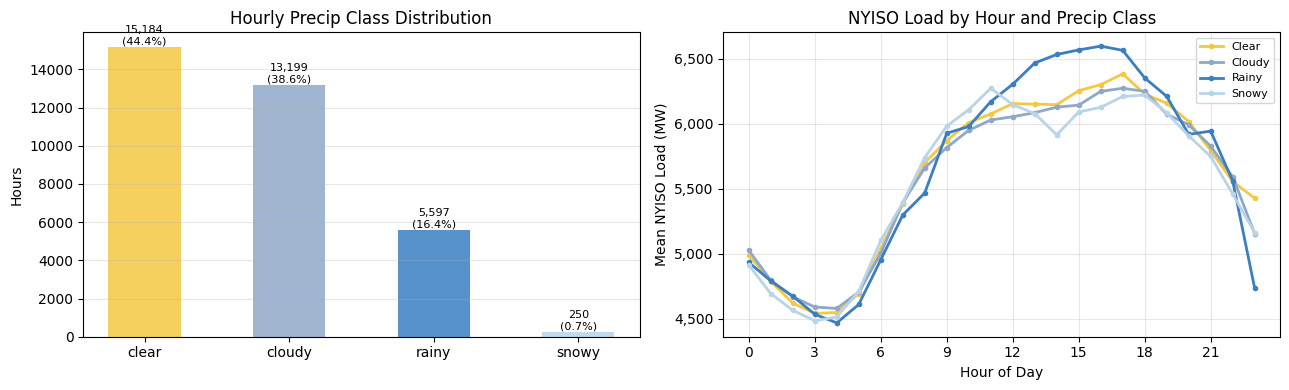

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: hourly class counts
counts = hourly["precip"].value_counts().reindex(CONDITION_ORDER)
bars = ax1.bar(CONDITION_ORDER, counts.values, color=[COLORS[c] for c in CONDITION_ORDER],
               alpha=0.85, width=0.5)
for bar, val in zip(bars, counts.values):
    pct = 100 * val / len(hourly)
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=8)
ax1.set_ylabel("Hours")
ax1.set_title("Hourly Precip Class Distribution")
ax1.grid(axis="y", alpha=0.3)

# Right: NYISO load profile by precip class
df_h = hourly.dropna(subset=["nyiso_load_mw"]).copy()
df_h["hour"] = df_h.index.hour
grouped = df_h.groupby(["hour", "precip"], observed=True)["nyiso_load_mw"].mean().reset_index()
for cond in CONDITION_ORDER:
    sub = grouped[grouped["precip"] == cond]
    ax2.plot(sub["hour"], sub["nyiso_load_mw"], label=cond.capitalize(),
             color=COLORS[cond], linewidth=2, marker="o", markersize=3)
ax2.set_xticks(range(0, 24, 3))
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Mean NYISO Load (MW)")
ax2.set_title("NYISO Load by Hour and Precip Class")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

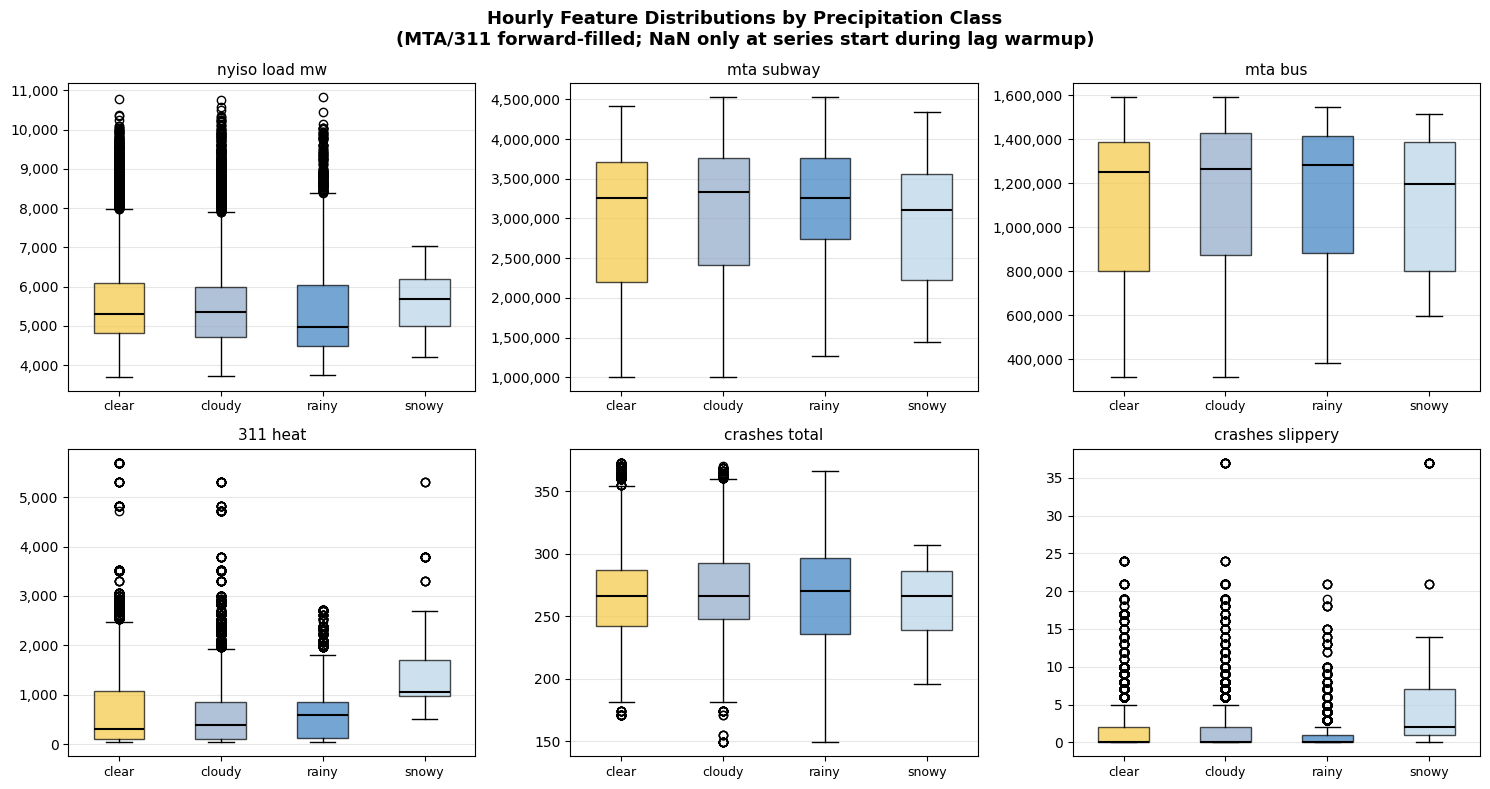

In [34]:
proxy_cols = [c for c in ["nyiso_load_mw", "mta_subway", "mta_bus", "311_heat", "311_flood", "311_snow", "crashes_total", "crashes_slippery"]
              if c in hourly.columns]

n_cols = min(3, len(proxy_cols))
n_rows = (len(proxy_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

n_total = len(hourly)
for ax, col in zip(axes, proxy_cols):
    null_pct = hourly[col].isna().sum() / n_total * 100
    groups = [hourly.loc[hourly["precip"] == c, col].dropna().values for c in CONDITION_ORDER]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    medianprops={"linewidth": 1.5, "color": "black"})
    for patch, cond in zip(bp["boxes"], CONDITION_ORDER):
        patch.set_facecolor(COLORS[cond])
        patch.set_alpha(0.7)
    ax.set_xticklabels(CONDITION_ORDER, fontsize=9)
    ax.set_title(f"{col.replace('_', '')}  ({null_pct:.1f}% null)", fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(proxy_cols):]:
    ax.set_visible(False)

fig.suptitle("Hourly Feature Distributions by Precipitation Class\n(MTA/311 forward-filled; NaN only at series start during lag warmup)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 6. Temperature Target

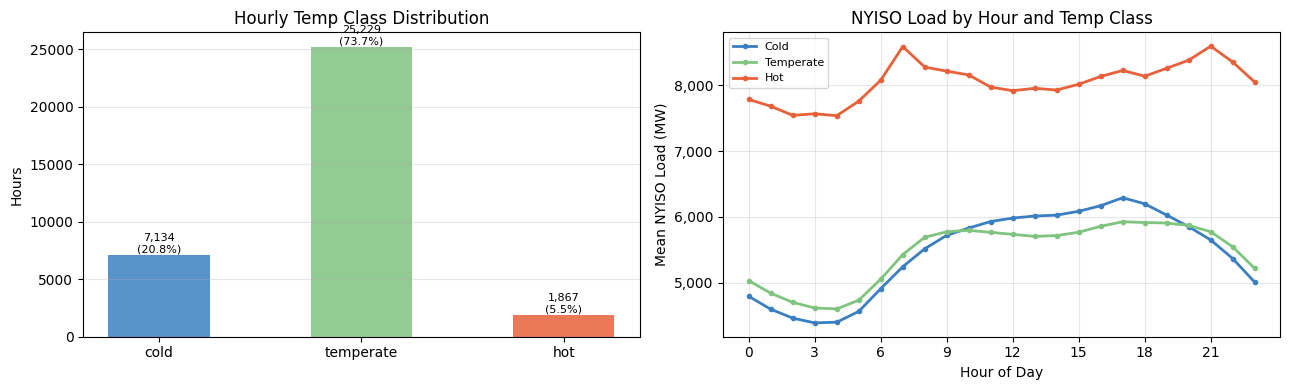

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: hourly class counts
counts = hourly["temp"].value_counts().reindex(TEMP_ORDER)
bars = ax1.bar(TEMP_ORDER, counts.values, color=[TEMP_COLORS[c] for c in TEMP_ORDER],
               alpha=0.85, width=0.5)
for bar, val in zip(bars, counts.values):
    pct = 100 * val / len(hourly)
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=8)
ax1.set_ylabel("Hours")
ax1.set_title("Hourly Temp Class Distribution")
ax1.grid(axis="y", alpha=0.3)

# Right: NYISO load profile by temp class
df_h = hourly.dropna(subset=["nyiso_load_mw"]).copy()
df_h["hour"] = df_h.index.hour
grouped = df_h.groupby(["hour", "temp"], observed=True)["nyiso_load_mw"].mean().reset_index()
for tc in TEMP_ORDER:
    sub = grouped[grouped["temp"] == tc]
    ax2.plot(sub["hour"], sub["nyiso_load_mw"], label=tc.capitalize(),
             color=TEMP_COLORS[tc], linewidth=2, marker="o", markersize=3)
ax2.set_xticks(range(0, 24, 3))
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Mean NYISO Load (MW)")
ax2.set_title("NYISO Load by Hour and Temp Class")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

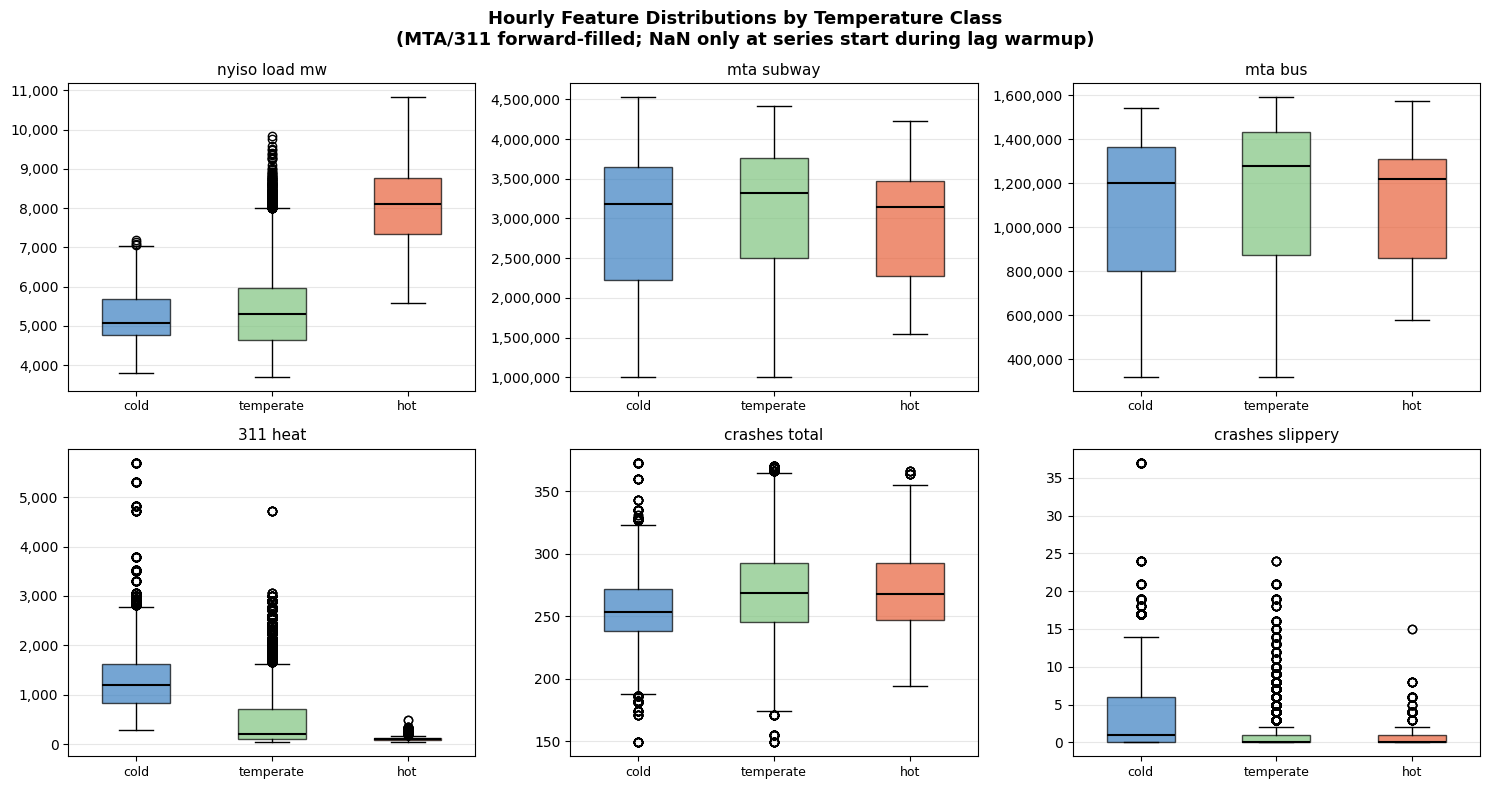

In [36]:
proxy_cols = [c for c in ["nyiso_load_mw", "mta_subway", "mta_bus", "311_heat", "311_flood", "311_snow", "crashes_total", "crashes_slippery"]
              if c in hourly.columns]

n_cols = min(3, len(proxy_cols))
n_rows = (len(proxy_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

n_total = len(hourly)
for ax, col in zip(axes, proxy_cols):
    null_pct = hourly[col].isna().sum() / n_total * 100
    groups = [hourly.loc[hourly["temp"] == tc, col].dropna().values for tc in TEMP_ORDER]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    medianprops={"linewidth": 1.5, "color": "black"})
    for patch, tc in zip(bp["boxes"], TEMP_ORDER):
        patch.set_facecolor(TEMP_COLORS[tc])
        patch.set_alpha(0.7)
    ax.set_xticklabels(TEMP_ORDER, fontsize=9)
    ax.set_title(f"{col.replace('_', '')}  ({null_pct:.1f}% null)", fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(proxy_cols):]:
    ax.set_visible(False)

fig.suptitle("Hourly Feature Distributions by Temperature Class\n(MTA/311 forward-filled; NaN only at series start during lag warmup)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

In [ ]:
## 4b. Target Distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

precip_counts = hourly["precip"].value_counts().reindex(CONDITION_ORDER).fillna(0)
ax1.bar(CONDITION_ORDER, precip_counts.values,
        color=[COLORS[c] for c in CONDITION_ORDER], edgecolor="white", linewidth=0.5)
for i, v in enumerate(precip_counts.values):
    ax1.text(i, v + precip_counts.max() * 0.01, f"{v/len(hourly)*100:.1f}%", ha="center", fontsize=10)
ax1.set_title("Precipitation Class Balance", fontsize=12, fontweight="bold")
ax1.set_ylabel("Hours")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax1.grid(axis="y", alpha=0.3)

temp_counts = hourly["temp"].value_counts().reindex(TEMP_ORDER).fillna(0)
ax2.bar(TEMP_ORDER, temp_counts.values,
        color=[TEMP_COLORS[c] for c in TEMP_ORDER], edgecolor="white", linewidth=0.5)
for i, v in enumerate(temp_counts.values):
    ax2.text(i, v + temp_counts.max() * 0.01, f"{v/len(hourly)*100:.1f}%", ha="center", fontsize=10)
ax2.set_title("Temperature Class Balance", fontsize=12, fontweight="bold")
ax2.set_ylabel("Hours")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Target Variable Distributions", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

In [ ]:
## 4c. Features Over Time
n_cols = min(3, len(proxy_cols))
n_rows = (len(proxy_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3 * n_rows), sharex=True)
axes = np.array(axes).flatten()

for ax, col in zip(axes, proxy_cols):
    s = hourly[col].dropna()
    ax.plot(s.index, s.values, linewidth=0.4, alpha=0.7, color=NAVY)
    ax.set_title(col.replace("_", " "), fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.grid(alpha=0.2)

for ax in axes[len(proxy_cols):]:
    ax.set_visible(False)

fig.suptitle("Features Over Time", fontsize=13, fontweight="bold")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 7. Hourly Correlations

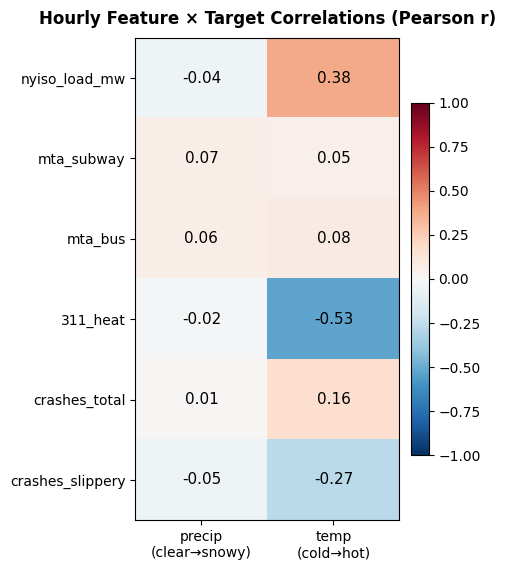

In [37]:
target_cols  = ["precip_int", "temp_int"]
feature_cols = [c for c in ["nyiso_load_mw", "mta_subway", "mta_bus", "311_heat", "311_flood", "311_snow", "crashes_total", "crashes_slippery"]
                if c in hourly.columns]

corr_df = hourly[feature_cols + target_cols].dropna()
corr = pd.DataFrame({t: corr_df[feature_cols].corrwith(corr_df[t]) for t in target_cols})

fig, ax = plt.subplots(figsize=(5, len(feature_cols) * 0.8 + 1))
im = ax.imshow(corr.values, cmap=LinearSegmentedColormap.from_list("navy_orange", [NAVY, "#F5F5F5", ORANGE]), vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(2))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(["precip\n(clear→snowy)", "temp\n(cold→hot)"], fontsize=10)
ax.set_yticklabels(feature_cols, fontsize=10)

for i in range(len(feature_cols)):
    for j in range(2):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=11)

plt.colorbar(im, ax=ax, fraction=0.06, pad=0.04)
ax.set_title("Hourly Feature × Target Correlations (Pearson r)", fontsize=12, fontweight="bold", pad=10)
fig.tight_layout()
plt.show()

## 8. Modeling

XGBoost multiclass classifier for each target.  
**Training:** temporal split (train ≤ 2023-12-31, val 2024-01–06, test 2024-07–12).  
**Evaluation:** temporal test set (future data) and random holdout (cross-time sample).  
Add entries to `splits` to extend the evaluation framework.

In [38]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import shap

In [39]:
proxy_cols = [c for c in ["nyiso_load_mw", "mta_subway", "mta_bus", "311_heat", "311_flood", "311_snow", "crashes_total", "crashes_slippery"]
              if c in hourly.columns]
feat_cols = proxy_cols

df_m = hourly[feat_cols + ["precip_int", "temp_int"]].dropna(subset=["precip_int", "temp_int"])

# Temporal split — models trained here
TRAIN_END = pd.Timestamp("2023-12-31")
VAL_END   = pd.Timestamp("2024-06-30")
t_tr  = df_m[df_m.index <= TRAIN_END]
t_val = df_m[(df_m.index > TRAIN_END) & (df_m.index <= VAL_END)]
t_te  = df_m[df_m.index > VAL_END]

# Random holdout — sampled across all time for comparison
rand_te = df_m.sample(frac=0.1, random_state=42)

print(f"temporal  train {len(t_tr):,}  val {len(t_val):,}  test {len(t_te):,}")
print(f"random    holdout {len(rand_te):,}")

train 27,326  val 3,416  test 3,416


In [40]:
def train_xgb(X_tr, y_tr, X_val, y_val, n_cls):
    m = XGBClassifier(
        objective="multi:softprob", num_class=n_cls,
        n_estimators=300, learning_rate=0.05, max_depth=5,
        early_stopping_rounds=20, eval_metric="mlogloss",
        verbosity=0, random_state=42,
    )
    m.fit(X_tr, y_tr, sample_weight=compute_sample_weight("balanced", y_tr),
          eval_set=[(X_val, y_val)], verbose=False)
    return m

model_precip = train_xgb(t_tr[feat_cols], t_tr["precip_int"], t_val[feat_cols], t_val["precip_int"], n_cls=4)
model_temp   = train_xgb(t_tr[feat_cols], t_tr["temp_int"],   t_val[feat_cols], t_val["temp_int"],   n_cls=3)
print(f"precip stopped at iter {model_precip.best_iteration}")
print(f"temp   stopped at iter {model_temp.best_iteration}")

precip stopped at iter 299
temp   stopped at iter 299


In [41]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def metrics_figure(splits):
    metric_names  = ['accuracy', 'precision', 'recall', 'auc_roc']
    split_colors  = {'temporal': NAVY, 'random': ORANGE}
    targets       = [('precip', model_precip, CONDITION_ORDER), ('temp', model_temp, TEMP_ORDER)]
    target_colors = {**COLORS, **TEMP_COLORS}
    fig, axes     = plt.subplots(2, 2, figsize=(14, 9))

    for row, (target, model, class_order) in enumerate(targets):
        ax_bar, ax_roc = axes[row, 0], axes[row, 1]
        width = 0.7 / len(splits)
        x     = np.arange(len(metric_names))

        for i, (split_name, te) in enumerate(splits.items()):
            y, X = te[f'{target}_int'], te[feat_cols]
            yp, yb = model.predict(X), model.predict_proba(X)
            vals = [accuracy_score(y, yp),
                    precision_score(y, yp, average='weighted', zero_division=0),
                    recall_score(y, yp, average='weighted'),
                    roc_auc_score(y, yb, multi_class='ovr', average='macro')]
            offset = (i - (len(splits) - 1) / 2) * width
            bars = ax_bar.bar(x + offset, vals, width, label=split_name,
                             color=split_colors.get(split_name, f'C{i}'), alpha=0.85)
            for bar, v in zip(bars, vals):
                ax_bar.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                            f'{v:.3f}', ha='center', va='bottom', fontsize=8)

        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels([m.replace('_', '\n') for m in metric_names], fontsize=10)
        ax_bar.set_ylim(0, 1.12)
        ax_bar.set_title(f'{target.capitalize()} — Metrics by Split', fontsize=11, fontweight='bold')
        ax_bar.legend(fontsize=9)
        ax_bar.grid(axis='y', alpha=0.3)

        te_t   = splits['temporal']
        y_true = te_t[f'{target}_int'].values
        y_prob = model.predict_proba(te_t[feat_cols])
        y_bin  = label_binarize(y_true, classes=range(len(class_order)))
        for cls_i, cls_name in enumerate(class_order):
            fpr, tpr, _ = roc_curve(y_bin[:, cls_i], y_prob[:, cls_i])
            ax_roc.plot(fpr, tpr, label=f'{cls_name}  AUC={auc(fpr,tpr):.2f}',
                        color=target_colors[cls_name], linewidth=1.8)
        ax_roc.plot([0,1],[0,1], '--', color='grey', linewidth=0.8)
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f'{target.capitalize()} — OvR ROC (temporal test)', fontsize=11, fontweight='bold')
        ax_roc.legend(fontsize=9)
        ax_roc.grid(alpha=0.2)

    fig.suptitle('Model Evaluation', fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()

# Add new splits here to extend evaluation
splits = {'temporal': t_te, 'random': rand_te}
metrics_figure(splits)


Precip (test)
  accuracy:  0.729
  precision: 0.739
  recall:    0.729
  auc-roc:   0.911

Temp   (test)
  accuracy:  0.915
  precision: 0.914
  recall:    0.915
  auc-roc:   0.981


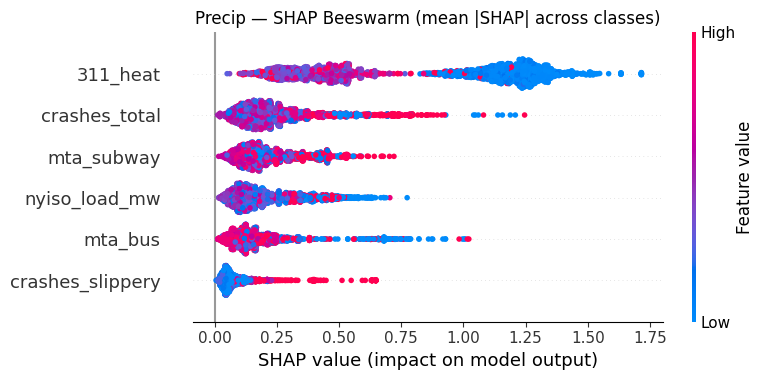

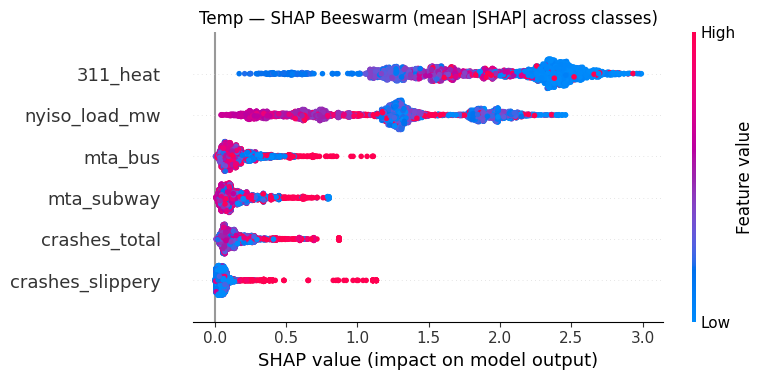

In [42]:
for model, label in [(model_precip, "Precip"), (model_temp, "Temp")]:
    explainer = shap.TreeExplainer(model)
    shap_exp  = explainer(X_te)
    # Average |SHAP| across output classes → one beeswarm per target
    mean_abs  = shap.Explanation(
        values        = np.abs(shap_exp.values).mean(-1),
        base_values   = shap_exp.base_values.mean(-1),
        data          = shap_exp.data,
        feature_names = feat_cols,
    )
    shap.plots.beeswarm(mean_abs, max_display=len(feat_cols),
                    color=LinearSegmentedColormap.from_list('navy_orange', [NAVY, '#F5F5F5', ORANGE]),
                    show=False)
    plt.title(f"{label} — SHAP Beeswarm (mean |SHAP| across classes)")
    plt.tight_layout()
    plt.show()